# **Gastric Cancer - Evaluating molecular subtype prediction in morphology-controlled histopathology datasets - DenseNet201**

This notebook explores the prediction of gastric cancer molecular subtypes using DenseNet201-based convolutional neural networks on histopathological images. It investigates whether these predictions hold when histological morphology is controlled, and evaluates model stability and sensitivity to learning rate variations (0.0001 and 0.001) using the Adam optimizer with early stopping.

### Requiriments

* `python=3.10.12`
* `tensorflow=2.15.0`
* `numpy=1.25.2`
* `pandas=2.0.3`
* `seaborn=0.12.2`
* `matplotlib=3.7.1`
* `opencv-python=4.8.0.76`
* `tensorflow=2.15.0`
* `scikit-learn=1.2.2.`

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import warnings
import platform

import cv2 as cv
import tensorflow as tf
from tensorflow import keras
import tensorflow.keras.backend as K
from tensorflow.keras.applications import VGG19
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Lambda
from tensorflow.keras.models import load_model
from tensorflow.keras import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
print("Python- Versão: ", platform.python_version())
print("TensorFLow - Versão: ",tf.__version__)

# Checar GPUs
if not tf.test.gpu_device_name():
    warnings.warn('GPU não encontrada.')
else:
    print(f'Dispositivo GPU padrão: {tf.test.gpu_device_name()}')
    print("Número de GPUs Disponíveis: ", len(tf.config.list_physical_devices('GPU')))


Python- Versão:  3.10.12
TensorFLow - Versão:  2.15.0
Dispositivo GPU padrão: /device:GPU:0
Número de GPUs Disponíveis:  1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzip Datasets
!unzip "/content/drive/MyDrive/Colab Notebooks/datasets/tubular-subtype-molecular-dataset.zip"

# Gerando Modelo

In [ ]:
train_dir = 'train'
val_dir = 'val'
test_dir = 'test'

# Especificações para o treinamento da rede
IMG_SHAPE = (224, 224, 3)
BATCH_SIZE = 32
EPOCHS = 100

In [ ]:
train_datagen = ImageDataGenerator(rescale=None)
valid_datagen = ImageDataGenerator(rescale=None)
test_datagen = ImageDataGenerator(rescale=None)

train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=BATCH_SIZE,
                                               target_size=(224, 224),
                                               class_mode="categorical")

val_data = valid_datagen.flow_from_directory(val_dir,
                                               batch_size=BATCH_SIZE,
                                               target_size=(224, 224),
                                               class_mode="categorical")

test_data = test_datagen.flow_from_directory(test_dir,
                                               batch_size=BATCH_SIZE,
                                               target_size=(224, 224),
                                               class_mode="categorical")

Found 11496 images belonging to 2 classes.
Found 3586 images belonging to 2 classes.
Found 3908 images belonging to 2 classes.


In [ ]:
# Criar a arquitetura da camada densa do modelo para o Fine Tuning
inputs = Input(shape=IMG_SHAPE)

xi = tf.cast(inputs, tf.float32)
xi = tf.keras.applications.densenet.preprocess_input(xi)

basemodel = densenet.DenseNet201(include_top=False,
                                 weights='imagenet',
                                 input_tensor = xi,
                                 input_shape=IMG_SHAPE,
                                 pooling='max')

x = Dense(256, activation="relu")(basemodel.output)
x = Dropout(0.2)(x)

x = BatchNormalization()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.2)(x)

x = BatchNormalization()(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.2)(x)

x = BatchNormalization()(x)
x = Dense(32, activation="relu")(x)
x = Dropout(0.2)(x)


outputs = Dense(2, activation="softmax")(x)

model = Model(inputs, outputs)

74836368/74836368 [==============================] - 0s 0us/step


In [ ]:
val_data.class_indices

{'CIN': 0, 'MSI': 1}

In [ ]:
class_names = list(val_data.class_indices.keys())
class_names

['CIN', 'MSI']

## Fine Tuning - Fase 1 (warm up) -> treina apenas a camada densa

In [ ]:
# Congela as camadas do modelo base (as camadas de convolução não serão treinadas novamente)
for layer in basemodel.layers:
    layer.trainable = False

In [ ]:
def check_units(y_true, y_pred):
    if y_pred.shape[1] != 1:
        y_pred = y_pred[:,1:2]
        y_true = y_true[:,1:2]
    return y_true, y_pred

def precision(y_true, y_pred):
    y_true, y_pred = check_units(y_true, y_pred)
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def recall(y_true, y_pred):
    y_true, y_pred = check_units(y_true, y_pred)
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def f1(y_true, y_pred):
    def recall(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
        recall = true_positives / (possible_positives + K.epsilon())
        return recall

    def precision(y_true, y_pred):
        true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
        precision = true_positives / (predicted_positives + K.epsilon())
        return precision
    y_true, y_pred = check_units(y_true, y_pred)
    precision = precision(y_true, y_pred)
    recall = recall(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

In [ ]:
base_learning_rate = 0.0001
opt = Adam(learning_rate=base_learning_rate)
# binary -> binary_crossentropy; categorical -> categorical_crossentropy
metrics=['acc', f1, precision, recall, tf.keras.metrics.AUC()]
model.compile(loss="binary_crossentropy", optimizer=opt, metrics=metrics)

In [ ]:
# Early Stopping do trinamento
early_stop = keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    min_delta=0.001,
    patience=7
)

model_ckpt = keras.callbacks.ModelCheckpoint(
    filepath='callbacks/melhor_modelo_callbacks_DenseNet201.hdf5',
    monitor='val_loss',
    save_best_only=True
)

callbacks = [early_stop, model_ckpt]

In [ ]:
# Fase 1 - treina apenas com algumas épocas (40% do total)
initial_epochs = int(EPOCHS*0.4)
history = model.fit(train_data,
                    epochs=initial_epochs,
                    steps_per_epoch=len(train_data),
                    validation_data=val_data,
                    validation_steps=len(val_data),
                    callbacks=callbacks)

Epoch 1/40
360/360 [==============================] - ETA: 0s - loss: 0.7367 - acc: 0.5966 - f1: 0.4578 - precision: 0.6893 - recall: 0.3627 - auc: 0.6349

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


360/360 [==============================] - 139s 312ms/step - loss: 0.7367 - acc: 0.5966 - f1: 0.4578 - precision: 0.6893 - recall: 0.3627 - auc: 0.6349 - val_loss: 0.9631 - val_acc: 0.4080 - val_f1: 0.3279 - val_precision: 0.4847 - val_recall: 0.2569 - val_auc: 0.3729
Epoch 2/40
360/360 [==============================] - 81s 224ms/step - loss: 0.5497 - acc: 0.7357 - f1: 0.7228 - precision: 0.7711 - recall: 0.6953 - auc: 0.8140 - val_loss: 1.1553 - val_acc: 0.4161 - val_f1: 0.4369 - val_precision: 0.4996 - val_recall: 0.4008 - val_auc: 0.3637
Epoch 3/40
360/360 [==============================] - 80s 222ms/step - loss: 0.4544 - acc: 0.7963 - f1: 0.7987 - precision: 0.8042 - recall: 0.8054 - auc: 0.8781 - val_loss: 1.2518 - val_acc: 0.4172 - val_f1: 0.5022 - val_precision: 0.4952 - val_recall: 0.5226 - val_auc: 0.3688
Epoch 4/40
360/360 [==============================] - 78s 218ms/step - loss: 0.3817 - acc: 0.8394 - f1: 0.8428 - precision: 0.8406 - recall: 0.8575 - auc: 0.9152 - val_loss:

## Fine Tuning - Fase 2 -> treina todo o modelo do fine tuning - descongela as camadas de convolução

In [ ]:
print("Número de camadas do modelo base: ", len(basemodel.layers))

Número de camadas do modelo base:  712


In [ ]:
# Descongelar as 30% camadas finais e que não seja do tipo BatchNormalization do modelo base
# Note que vpcê pode adicionar mais camadas se o modelo não for muito grande
count = 0
for layer in basemodel.layers[-int(len(basemodel.layers)*0.3):]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

In [ ]:
# É necessário diminuir a base_learning_rate para que o modelo não tenha convergência muito rápida
# pois se trata d eum modelo grande
opt = Adam(learning_rate=base_learning_rate/10)
model.compile(loss="categorical_crossentropy", optimizer=opt, metrics=metrics)

In [ ]:
# EarlyStopping do trinamento
early_stop2 = keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    min_delta=0.001,
    patience=7
)

model_ckpt2 = keras.callbacks.ModelCheckpoint(
    filepath='callbacks/melhor_modelo_callbacks_DenseNet201.hdf5',
    monitor='val_loss',
    save_best_only=True
)

callbacks2 = [early_stop2, model_ckpt2]

In [ ]:
# Fase 2 - treina apenas com a quantidade de épocas que faltam (60% finais)
# Note que iniciará de initial_epoch=history.epoch[-1]
history_fine = model.fit(train_data,
                    epochs=EPOCHS,
                    initial_epoch=history.epoch[-1],
                    steps_per_epoch=len(train_data),
                    validation_data=val_data,
                    validation_steps=len(val_data),
                    callbacks=callbacks2)

Epoch 8/100
360/360 [==============================] - 124s 271ms/step - loss: 0.2482 - acc: 0.9148 - f1: 0.9161 - precision: 0.9170 - recall: 0.9221 - auc: 0.8487 - val_loss: 3.2568 - val_acc: 0.4152 - val_f1: 0.4776 - val_precision: 0.4941 - val_recall: 0.4746 - val_auc: 0.3946
Epoch 9/100
360/360 [==============================] - 91s 253ms/step - loss: 0.1852 - acc: 0.9295 - f1: 0.9289 - precision: 0.9290 - recall: 0.9367 - auc: 0.9808 - val_loss: 3.3414 - val_acc: 0.4214 - val_f1: 0.4569 - val_precision: 0.5124 - val_recall: 0.4236 - val_auc: 0.3953
Epoch 10/100
360/360 [==============================] - 96s 266ms/step - loss: 0.1404 - acc: 0.9474 - f1: 0.9464 - precision: 0.9446 - recall: 0.9547 - auc: 0.9877 - val_loss: 3.2520 - val_acc: 0.4255 - val_f1: 0.4493 - val_precision: 0.5127 - val_recall: 0.4146 - val_auc: 0.3998
Epoch 11/100
360/360 [==============================] - 92s 257ms/step - loss: 0.1128 - acc: 0.9574 - f1: 0.9573 - precision: 0.9573 - recall: 0.9622 - auc: 0

## Métricas

In [ ]:
def print_confusion_matrix(confusion_matrix, class_names, figsize = (10,7), fontsize=11):
    df_cm = pd.DataFrame(
        confusion_matrix, index=class_names, columns=class_names,
    )
    fig = plt.figure(figsize=figsize)
    try:
        heatmap = sns.heatmap(df_cm, cmap="YlGnBu", annot=True, fmt="d")
    except ValueError:
        raise ValueError("Confusion matrix values must be integers.")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=30, ha='right', fontsize=fontsize)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    #return fig

In [ ]:
## Conjunto de Teste ###
def matrix_and_metrics(model, test_data, num_test):
    print ("### Matriz de confusão para o conjunto de teste ###")


    #Confution Matrix
    Y_pred = model.predict(test_data, num_test, verbose=1)

    test_preds = np.argmax(Y_pred, axis=-1)

    l=test_preds.shape[0]

    test_trues = test_data.classes

    cm = confusion_matrix(test_trues, test_preds)


    print_confusion_matrix(cm, ['benign', 'malignant'], figsize = (5,5), fontsize=11)

    # Accuracy and Loss for the Test set
    loss, acc, f1, pre, rec, aroc = model.evaluate_generator(test_data, num_test, verbose=1)

    # Final accuracy and loss
    print ("Test accuracy: %.3f" % acc)
    print ("Test f1-score: %.3f" % f1)
    print ("Test precision: %.3f" % pre)
    print ("Test recall: %.3f" % rec)
    print ("Test AROC: %.3f" % aroc)
    print ("Test loss: %.3f" % loss)

    return loss, acc, f1, pre, rec, aroc

# Resultados

### Matriz de confusão para o conjunto de teste ###
123/123 [==============================] - 31s 222ms/step


<ipython-input-21-5b3db25ae369>:21: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  loss, acc, f1, pre, rec, aroc = model.evaluate_generator(test_data, num_test, verbose=1)


 122/3908 [..............................] - ETA: 9:58 - loss: 2.0708 - acc: 0.6468 - f1: 0.6808 - precision: 0.6819 - recall: 0.6918 - auc: 0.6583

3908/3908 [==============================] - 20s 5ms/step - loss: 2.0713 - acc: 0.6466 - f1: 0.6807 - precision: 0.6804 - recall: 0.6943 - auc: 0.6582
Test accuracy: 0.647
Test f1-score: 0.681
Test precision: 0.680
Test recall: 0.694
Test AROC: 0.658
Test loss: 2.071


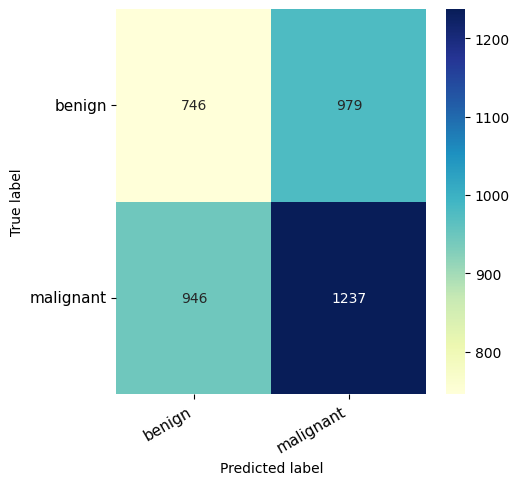

In [ ]:
# lr = 0,0001
num_test = test_data.samples
loss_0, acc_0, f1_0, pre_0, rec_0, aroc_0 = matrix_and_metrics(model, test_data, num_test)

### Matriz de confusão para o conjunto de teste ###
123/123 [==============================] - 31s 230ms/step


<ipython-input-21-5b3db25ae369>:21: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  loss, acc, f1, pre, rec, aroc = model.evaluate_generator(test_data, num_test, verbose=1)


 122/3908 [..............................] - ETA: 10:41 - loss: 2.0489 - acc: 0.5353 - f1: 0.6455 - precision: 0.5612 - recall: 0.7741 - auc: 0.6126

3908/3908 [==============================] - 21s 5ms/step - loss: 2.0509 - acc: 0.5351 - f1: 0.6403 - precision: 0.5567 - recall: 0.7678 - auc: 0.6121
Test accuracy: 0.535
Test f1-score: 0.640
Test precision: 0.557
Test recall: 0.768
Test AROC: 0.612
Test loss: 2.051


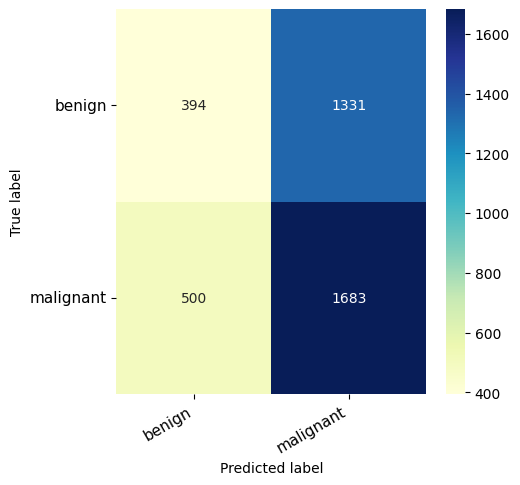

In [ ]:
# lr = 0,001
num_test = test_data.samples
loss_0, acc_0, f1_0, pre_0, rec_0, aroc_0 = matrix_and_metrics(model, test_data, num_test)